# Chapter 5 - Analysis Notebook

Reproduces every figure and in-text statistic in **Chapter 5: Cross-State Variation in Identification**.

Inputs: `idea_db_v2.sqlite`. Outputs: PNG figures in `figures/`. Run top-to-bottom; no network required.

Uses `v_identification_rate` (the canonical metric; 19 years, SY2005-06 to SY2023-24). Wisconsin is NULL for SY2016-17 through SY2019-20 by suppression - those years drop out naturally. Texas cap dates and the OSEP finding are external facts cited in the chapter text.

In [1]:
import sqlite3, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB = '../_shared/idea_db_v2.sqlite'
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
con = sqlite3.connect(DB)
def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

## 1. State identification-rate panel and dispersion

In [2]:
df = q('''SELECT school_year AS sy, state_code AS st, pct_identified AS pct
          FROM v_identification_rate WHERE pct_identified IS NOT NULL''')
piv = df.pivot(index='sy', columns='st', values='pct')
years = list(piv.index)

disp = pd.DataFrame({
    'n': df.groupby('sy')['pct'].count(),
    'min': piv.min(axis=1), 'median': piv.median(axis=1), 'max': piv.max(axis=1),
    'max_min_ratio': piv.max(axis=1)/piv.min(axis=1),
    'CV': piv.std(axis=1)/piv.mean(axis=1),
}).loc[['2005-06','2014-15','2023-24']]
disp.round(3)

,n,min,median,max,max_min_ratio,CV
sy,,,,,,
2005-06,51,10.506,14.390,19.998,1.903,0.144
2014-15,50,8.629,13.576,17.842,2.068,0.155
2023-24,50,11.944,15.683,22.054,1.846,0.162


## 2. Ranked states, SY2023-24 (Figure 5.1, Table 5.1 inputs)

,st,pct
914,HI,11.9
921,LA,12.5
916,ID,12.6
923,MD,13.4
944,TN,13.5
913,GA,13.6
911,DE,20.2
951,WV,20.2
922,MA,20.8
936,NY,21.6


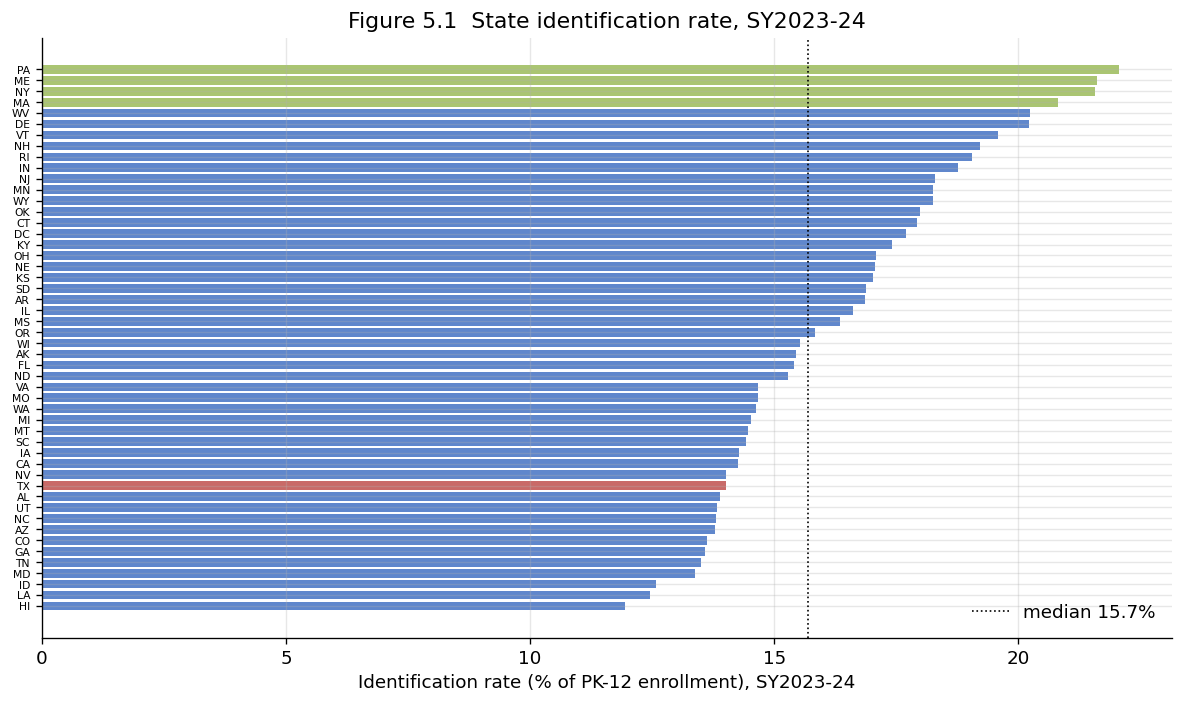

In [3]:
last = df[df['sy']=='2023-24'].sort_values('pct')
fig, ax = plt.subplots(figsize=(10,6))
colors = ['#c0504d' if s=='TX' else ('#9bbb59' if s in ('MA','PA','NY','ME') else '#4472c4') for s in last['st']]
ax.barh(last['st'], last['pct'], color=colors, alpha=0.85)
ax.axvline(last['pct'].median(), color='black', ls=':', lw=1, label=f"median {last['pct'].median():.1f}%")
ax.set_xlabel('Identification rate (% of PK-12 enrollment), SY2023-24')
ax.tick_params(axis='y', labelsize=6.5); ax.legend(frameon=False)
ax.set_title('Figure 5.1  State identification rate, SY2023-24')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig5_1_state_ranked.png', bbox_inches='tight')
pd.concat([last.head(6)[['st','pct']], last.tail(6)[['st','pct']]]).round(1)

## 3. The Texas cap (Figure 5.2)

National enrollment-weighted rate vs Texas. The shaded window is the TEA 8.5% cap era (2004-2017); the arrow marks the 2018 OSEP finding of an IDEA violation. Both are external facts (not in the database).

sy
2005-06    11.2
2006-07    10.7
2007-08    10.1
2008-09     9.5
2009-10     9.2
2010-11     9.0
2011-12     8.8
2012-13     8.7
2013-14     8.6
2014-15     8.6
2015-16     8.7
2016-17     8.9
2017-18     9.2
2018-19     9.8
2019-20    10.3
2020-21    11.3
2021-22    11.7
2022-23    12.7
2023-24    14.0
Name: TX, dtype: float64

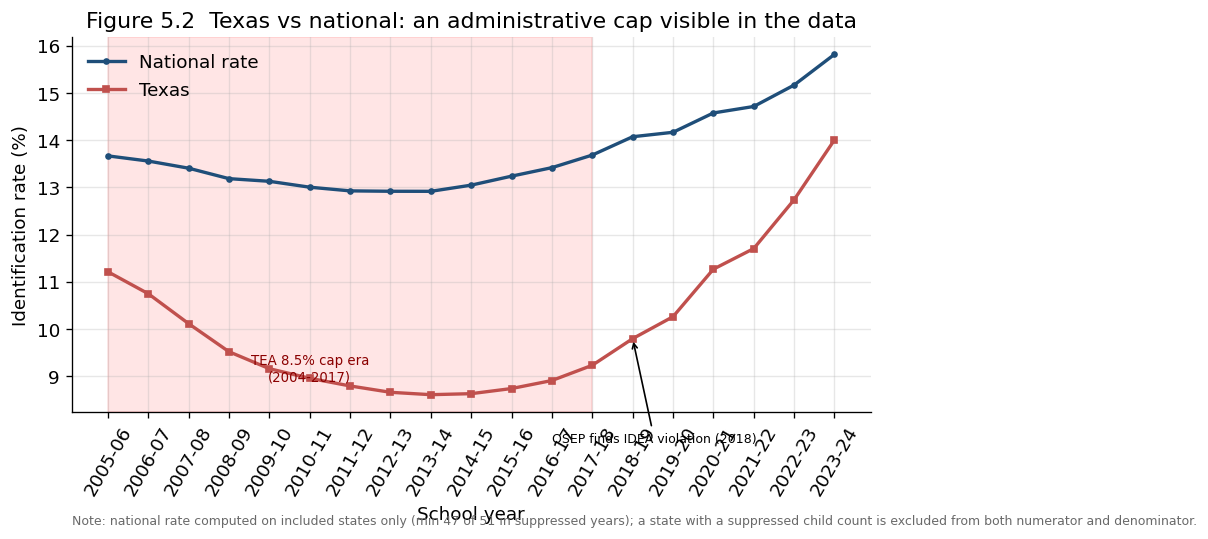

In [4]:
# 분모 비대칭 제거: raw 직접 SUM 대신 v_identification_rate_national 사용.
# 전국선이 억제 연도(특히 2016-17~2019-20, WI 등 제외)에서 +0.2~0.5%p 상향.
natdf = q('''SELECT school_year AS sy, pct_identified AS pct, n_states_included
  FROM v_identification_rate_national ORDER BY sy''')
natw = natdf.set_index('sy')['pct']
fig, ax = plt.subplots(figsize=(9.5,4.8))
ax.plot(years, natw.reindex(years).values, color='#1f4e79', lw=2, marker='o', ms=3, label='National rate')
ax.plot(years, piv['TX'].values, color='#c0504d', lw=2, marker='s', ms=4, label='Texas')
ax.axvspan('2005-06','2017-18', alpha=0.10, color='red')
ax.text('2010-11', 8.9, 'TEA 8.5% cap era\n(2004-2017)', fontsize=8, color='darkred', ha='center')
ax.annotate('OSEP finds IDEA violation (2018)', xy=('2018-19',9.8), xytext=('2016-17',7.6),
            fontsize=7.5, arrowprops=dict(arrowstyle='->'))
ax.set_ylabel('Identification rate (%)'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60); ax.legend(frameon=False)
ax.set_title('Figure 5.2  Texas vs national: an administrative cap visible in the data')
# 억제 주 제외 주석: 전국선은 분자 결측 주를 제외하고 산출됨(억제 연도 < 51주)
_minN = int(natdf['n_states_included'].min())
if _minN < 51:
    ax.text(0.0, -0.30, f'Note: national rate computed on included states only '
            f'(min {_minN} of 51 in suppressed years); a state with a suppressed '
            f'child count is excluded from both numerator and denominator.',
            transform=ax.transAxes, fontsize=7.5, color='dimgray')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig5_2_texas_cap.png', bbox_inches='tight')
piv['TX'].round(1)

## 4. Persistence of state rank (Figure 5.3)

First-year vs last-year rate. A high Spearman rank correlation means the cross-state ordering is durable - states do not shuffle - which points to stable state-level policy/practice rather than noise.

Spearman rho: 0.79
Persistently lowest: ['TX', 'ID', 'CO', 'HI', 'CA']
Persistently highest: ['RI', 'PA', 'NY', 'MA', 'ME']


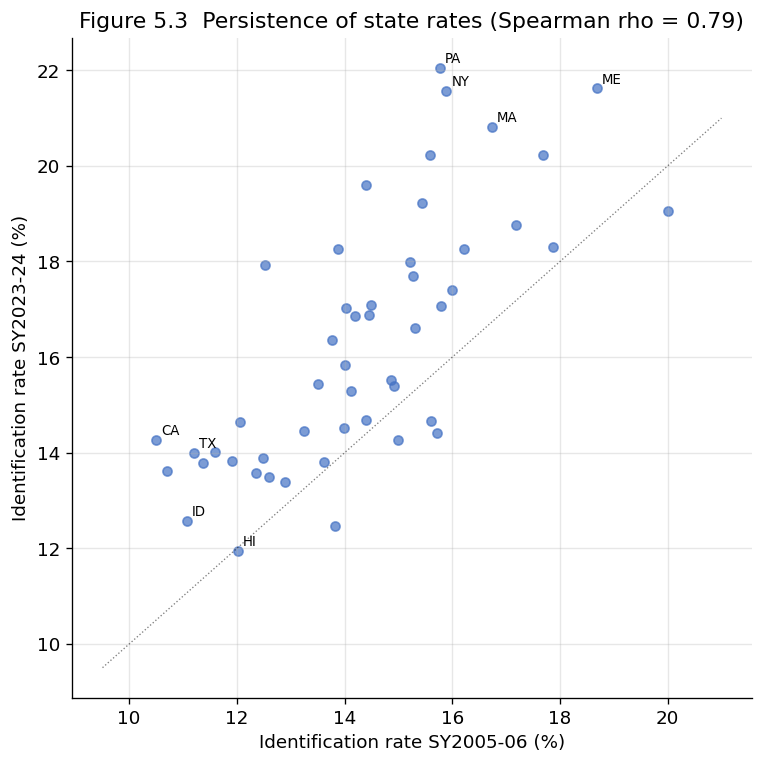

In [5]:
common = piv.loc['2005-06'].dropna().index.intersection(piv.loc['2023-24'].dropna().index)
x = piv.loc['2005-06', common]; y = piv.loc['2023-24', common]
rho = np.corrcoef(x.rank(), y.rank())[0,1]
fig, ax = plt.subplots(figsize=(6.5,6.5))
ax.scatter(x, y, color='#4472c4', alpha=0.7, s=30)
for s in ['TX','MA','ME','PA','NY','HI','CA','ID']:
    if s in common: ax.annotate(s, (x[s], y[s]), fontsize=8, xytext=(3,3), textcoords='offset points')
lims = [x.min()-1, x.max()+1]; ax.plot(lims, lims, 'k:', lw=0.8, alpha=0.5)
ax.set_xlabel('Identification rate SY2005-06 (%)'); ax.set_ylabel('Identification rate SY2023-24 (%)')
ax.set_title(f'Figure 5.3  Persistence of state rates (Spearman rho = {rho:.2f})')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig5_3_persistence.png', bbox_inches='tight')

mean_rank = piv.rank(axis=1).mean(axis=0).sort_values()
print('Spearman rho:', round(rho,2))
print('Persistently lowest:', list(mean_rank.head(5).index))
print('Persistently highest:', list(mean_rank.tail(5).index))

In [6]:
con.close()
print('Chapter 5 figures written to', FIGDIR)

Chapter 5 figures written to figures
